# IMD Baseline Sensitivity Analysis
**Robustness Check: 2010 vs 2019 IMD Classification**

---

### Purpose

The main framework assigns MSOA wealth deciles using a **fixed 2010 IMD baseline** applied longitudinally to both the 2011 and 2021 Census OD data. This notebook tests whether the cascade indicators are sensitive to the choice of baseline year by re-estimating all metrics under an alternative **2019 IMD classification** and comparing the results.

The main question of this analysis is *Given IMD 2019 available, which is closer to 2021. Why did we stick with 2010?* It should be defisible to use 2010 IMD for 2011 OD data.

### Design

| Combination | OD Data | IMD Baseline | Role |
|-------------|---------|--------------|------|
| A | 2011 Census | IMD 2010 | Main framework (2011 period) |
| B | 2011 Census | IMD 2019 | Sensitivity counterfactual |
| C | 2021 Census | IMD 2010 | Main framework (2021 period) |
| D | 2021 Census | IMD 2019 | Sensitivity counterfactual |

### Metrics Compared

| Metric | Formula |
|--------|---------|
| Inflow Wealthier | Migrants arriving from higher-decile MSOAs |
| Outflow Poorer | Migrants leaving to lower-decile MSOAs |
| Net Cascade | Inflow_Wealthier − Outflow_Poorer |
| CFI Churn | Inflow_Wealthier + Outflow_Poorer |
| CFI Rate | (Inflow_W × Outflow_P) / Total_Migration |
| % Inflow Wealthier | Inflow_Wealthier / Total_Inflow × 100 |

### Expected Result

If cascade indicators are robust, metrics computed under the 2010 and 2019 baselines should be highly correlated (r > 0.80), and validation correlations with IMD Percentile Change should remain consistent in sign, significance, and relative magnitude.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pyprojroot import here
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)

ROOT = here()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# ---- File paths (adjust if needed) ----
imd_2010_path       = DATA_DIR / 'imd_2010.xls'
imd_2019_path       = DATA_DIR / 'imd_2019.csv'
census_od_2021_path = DATA_DIR / 'census_od_2021_msoa.csv'
census_od_2011_path = DATA_DIR / 'census_od_2011_oa.csv'
lookup_path         = DATA_DIR / 'NSPCL_NOV22_UK_LU.csv'
msoa_lookup_path    = DATA_DIR / 'msoa_2011_to_2021_lookup.csv'

In [11]:
# ---- Load IMD ----
imd_2019 = pd.read_csv(imd_2019_path)
imd_2019.columns = imd_2019.columns.str.strip()

imd_2010 = pd.read_excel(imd_2010_path, sheet_name='IMD 2010')
imd_2010.columns = imd_2010.columns.str.strip()


# ---- Load Census O-D 2021 (MSOA level) ----
census_od_2021 = pd.read_csv(census_od_2021_path)

# ---- Column definitions (from census_od_2011 metadata) ----
# Col A = "Area of usual residence"      = DESTINATION
# Col B = "Area of address 1 year ago"   = ORIGIN
# Col C = "Persons"                       = COUNT
OD_2011_ORIGIN_COL = 'origin_oa'
OD_2011_DEST_COL   = 'dest_oa'
OD_2011_COUNT_COL  = 'persons'

# ---- Load Census O-D 2011 (OA level) ----
census_od_2011_raw = pd.read_csv(
    census_od_2011_path,
    header=None,
    names=['dest_oa', 'origin_oa', 'persons'],  # A=dest, B=origin, C=count
    dtype={'dest_oa': str, 'origin_oa': str, 'persons': int}
)

# Log special codes before they drop out
special_mask = census_od_2011_raw['origin_oa'].str.startswith('OD')
print(f'Rows with special origin codes (cross-border etc): '
      f'{special_mask.sum():,} — these will be excluded')

# ---- Load Lookups ----
lookup = pd.read_csv(lookup_path, encoding='ISO-8859-1', low_memory=False)
msoa_11_21 = pd.read_csv(msoa_lookup_path)

print('All data loaded.')

Rows with special origin codes (cross-border etc): 116,320 — these will be excluded
All data loaded.


## 2. Geography Harmonisation

Replicated from the main data processing notebook for reproducibility.

In [12]:
# ---- 2a. MSOA 2021 → 2011 mapping (for 2021 O-D data) ----
msoa_11_21.columns = msoa_11_21.columns.str.strip().str.lower()

unchanged = msoa_11_21[msoa_11_21['msoa11cd'] == msoa_11_21['msoa21cd']].copy()
msoa21_to_11 = dict(zip(unchanged['msoa21cd'], unchanged['msoa11cd']))

print(f'Total MSOAs in lookup: {len(msoa_11_21)}')
print(f'Unchanged (usable):    {len(unchanged)}')
print(f'Dropped (split/merged): {len(msoa_11_21) - len(unchanged)}')

# ---- 2b. OA → MSOA mapping (for 2011 O-D data) ----
# Extract unique OA-to-MSOA assignments from the postcode lookup
oa_to_msoa = (
    lookup[['oa11cd', 'msoa11cd']]
    .drop_duplicates()
    .dropna()
)
# Sanity check: each OA should map to exactly one MSOA
oa_dup = oa_to_msoa.groupby('oa11cd')['msoa11cd'].nunique()
assert (oa_dup == 1).all(), f'{(oa_dup > 1).sum()} OAs map to multiple MSOAs!'
oa_to_msoa_dict = dict(zip(oa_to_msoa['oa11cd'], oa_to_msoa['msoa11cd']))

print(f'OA-to-MSOA mappings: {len(oa_to_msoa_dict):,}')

# ---- 2c. Map 2021 O-D to 2011 MSOA codes ----
ORIGIN_COL_2021 = 'Migrant MSOA one year ago code'
DEST_COL_2021   = 'Middle layer Super Output Areas code'

census_od_2021['origin_msoa11'] = census_od_2021[ORIGIN_COL_2021].map(msoa21_to_11)
census_od_2021['dest_msoa11']   = census_od_2021[DEST_COL_2021].map(msoa21_to_11)

n_total = len(census_od_2021)
n_mapped = census_od_2021[['origin_msoa11', 'dest_msoa11']].notna().all(axis=1).sum()
print(f'2021 O-D records: {n_total:,}')
print(f'Both endpoints mapped to 2011 codes: {n_mapped:,} ({n_mapped/n_total*100:.1f}%)')

# ---- 2d. Aggregate 2011 O-D from OA to MSOA level ----
census_od_2011 = census_od_2011_raw.copy()

# Map OA codes to MSOA codes
census_od_2011['origin_msoa11'] = census_od_2011[OD_2011_ORIGIN_COL].map(oa_to_msoa_dict)
census_od_2011['dest_msoa11']   = census_od_2011[OD_2011_DEST_COL].map(oa_to_msoa_dict)

n_total_11 = len(census_od_2011)
n_mapped_11 = census_od_2011[['origin_msoa11', 'dest_msoa11']].notna().all(axis=1).sum()
print(f'2011 O-D records (OA level): {n_total_11:,}')
print(f'Both endpoints mapped to MSOA: {n_mapped_11:,} ({n_mapped_11/n_total_11*100:.1f}%)')

# Aggregate to MSOA-to-MSOA flows
census_od_2011_msoa = (
    census_od_2011
    .dropna(subset=['origin_msoa11', 'dest_msoa11'])
    .groupby(['origin_msoa11', 'dest_msoa11'])[OD_2011_COUNT_COL]
    .sum()
    .reset_index()
    .rename(columns={OD_2011_COUNT_COL: 'count'})
)

# Remove non-movers (same origin and destination MSOA)
census_od_2011_msoa = census_od_2011_msoa[
    census_od_2011_msoa['origin_msoa11'] != census_od_2011_msoa['dest_msoa11']
].copy()

print(f'Aggregated MSOA-to-MSOA flow records (2011): {len(census_od_2011_msoa):,}')
print(f'Total migrants (2011): {census_od_2011_msoa["count"].sum():,.0f}')

Total MSOAs in lookup: 7201
Unchanged (usable):    7080
Dropped (split/merged): 121
OA-to-MSOA mappings: 232,044
2021 O-D records: 1,490,726
Both endpoints mapped to 2011 codes: 1,349,030 (90.5%)
2011 O-D records (OA level): 3,709,939
Both endpoints mapped to MSOA: 3,556,066 (95.9%)
Aggregated MSOA-to-MSOA flow records (2011): 1,374,520
Total migrants (2011): 5,124,913


## 3. London Filter & IMD Aggregation to MSOA

In [13]:
london_boroughs = [
    'City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent',
    'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich',
    'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering',
    'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea',
    'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham',
    'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton',
    'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster'
]

london_lookup = (
    lookup[lookup['ladnm'].isin(london_boroughs)]
    [['lsoa11cd', 'msoa11cd', 'ladnm']]
    .drop_duplicates()
)

# Set of London MSOA codes (used for filtering flows)
london_msoas = set(london_lookup['msoa11cd'].unique())

print(f'London LSOAs: {london_lookup["lsoa11cd"].nunique()}')
print(f'London MSOAs: {len(london_msoas)}')
print(f'Boroughs:     {london_lookup["ladnm"].nunique()}')

# Column name shortcuts
IMD_2010_LSOA_COL  = 'LSOA CODE'
IMD_2010_SCORE_COL = 'IMD SCORE'
IMD_2010_RANK_COL  = 'RANK OF IMD SCORE (where 1 is most deprived)'

IMD_2019_LSOA_COL  = 'LSOA code (2011)'
IMD_2019_SCORE_COL = 'Index of Multiple Deprivation (IMD) Score'
IMD_2019_RANK_COL  = 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'

# ---- Normalise ranks to percentiles ----
# CRITICAL: 2010 has 32,482 LSOAs, 2019 has 32,844 LSOAs.
# Raw ranks are NOT comparable across years. Converting to percentiles
# (rank / n) places every LSOA on a 0–1 scale regardless of total count.
# Higher percentile = less deprived (rank 1 = most deprived → low percentile).
n_lsoa_2010 = len(imd_2010)
n_lsoa_2019 = len(imd_2019)
 
imd_2010['IMD_Percentile_2010'] = (
    imd_2010[IMD_2010_RANK_COL] / n_lsoa_2010
)
imd_2019['IMD_Percentile_2019'] = (
    imd_2019[IMD_2019_RANK_COL] / n_lsoa_2019
)
 
print(f"IMD 2010: {n_lsoa_2010:,} LSOAs (England)")
print(f"IMD 2019: {n_lsoa_2019:,} LSOAs (England)")
print(f"Ranks normalised to percentiles (0 = most deprived, 1 = least)")

# ---- Population weights (mid-2015 from IMD 2019 file) ----
POP_COL = 'Total population: mid 2015 (excluding prisoners)'

# Build LSOA-level population lookup (2011 LSOA codes → population)
lsoa_pop = (
    imd_2019[[IMD_2019_LSOA_COL, POP_COL]]
    .rename(columns={IMD_2019_LSOA_COL: 'lsoa11cd', POP_COL: 'pop'})
    .copy()
)

# Helper: population-weighted mean
def pop_weighted_mean(df, value_col, weight_col='pop'):
    """Population-weighted mean, falling back to simple mean if weights are all zero."""
    w = df[weight_col]
    if w.sum() == 0:
        return df[value_col].mean()
    return np.average(df[value_col], weights=w)

# ---- IMD 2010 → MSOA (population-weighted) ----
imd_2010_london = pd.merge(
    imd_2010[[IMD_2010_LSOA_COL, IMD_2010_SCORE_COL,
              IMD_2010_RANK_COL, 'IMD_Percentile_2010']],
    london_lookup,
    left_on=IMD_2010_LSOA_COL, right_on='lsoa11cd'
)
# Attach population weights (mid-2015 as best available proxy for 2010)
imd_2010_london = pd.merge(imd_2010_london, lsoa_pop, on='lsoa11cd', how='left')
imd_2010_london['pop'] = imd_2010_london['pop'].fillna(0)

msoa_imd_2010 = (
    imd_2010_london
    .groupby(['msoa11cd', 'ladnm'])
    .apply(lambda g: pd.Series({
        'IMD_2010':        pop_weighted_mean(g, IMD_2010_SCORE_COL),
        'IMD_Rank_2010':   pop_weighted_mean(g, IMD_2010_RANK_COL),
        'IMD_Pctile_2010': pop_weighted_mean(g, 'IMD_Percentile_2010'),
    }))
    .reset_index()
)

# ---- IMD 2019 → MSOA (population-weighted) ----
imd_2019_london = pd.merge(
    imd_2019[[IMD_2019_LSOA_COL, IMD_2019_SCORE_COL,
              IMD_2019_RANK_COL, 'IMD_Percentile_2019', POP_COL]],
    london_lookup,
    left_on=IMD_2019_LSOA_COL, right_on='lsoa11cd'
)
imd_2019_london = imd_2019_london.rename(columns={POP_COL: 'pop'})
imd_2019_london['pop'] = imd_2019_london['pop'].fillna(0)

msoa_imd_2019 = (
    imd_2019_london
    .groupby('msoa11cd')
    .apply(lambda g: pd.Series({
        'IMD_2019':        pop_weighted_mean(g, IMD_2019_SCORE_COL),
        'IMD_Rank_2019':   pop_weighted_mean(g, IMD_2019_RANK_COL),
        'IMD_Pctile_2019': pop_weighted_mean(g, 'IMD_Percentile_2019'),
    }))
    .reset_index()
)

print(f'MSOA IMD 2010: {len(msoa_imd_2010)} MSOAs')
print(f'MSOA IMD 2019: {len(msoa_imd_2019)} MSOAs')
print(f'Population weights: mid-2015 estimates from IMD 2019 file')


# ---- Combine & compute change metrics ----
msoa_wealth = pd.merge(msoa_imd_2010, msoa_imd_2019, on='msoa11cd', how='inner')
 
# PRIMARY METRIC: Percentile change (rank-based, comparable across years)
# Positive = MSOA moved UP in national ranking = became relatively LESS deprived
msoa_wealth['IMD_Pctile_Change'] = (
    msoa_wealth['IMD_Pctile_2019'] - msoa_wealth['IMD_Pctile_2010']
)
 
# SECONDARY METRIC: Raw score change (kept for descriptive context only)
# Negative = lower deprivation score in 2019 = less deprived
# NOT strictly comparable across years — use with caveats
msoa_wealth['IMD_Score_Change'] = (
    msoa_wealth['IMD_2019'] - msoa_wealth['IMD_2010']
)
 
print(f'\nLondon MSOAs with both IMD years: {len(msoa_wealth)}')
print(f'\n--- Percentile Change (PRIMARY) ---')
print(f'  Positive = moved up in national ranking = less deprived')
print(msoa_wealth['IMD_Pctile_Change'].describe().round(4))
print(f'\n--- Score Change (SECONDARY) ---')
print(f'  Negative = lower deprivation score = less deprived')
print(msoa_wealth['IMD_Score_Change'].describe().round(2))

# Summary
n_up = (msoa_wealth['IMD_Pctile_Change'] > 0).sum()
n_down = (msoa_wealth['IMD_Pctile_Change'] < 0).sum()
n_total = len(msoa_wealth)
print(f'Rank-based: {n_up} MSOAs moved UP ({n_up/n_total*100:.1f}%), '
      f'{n_down} moved DOWN ({n_down/n_total*100:.1f}%)')

London LSOAs: 4835
London MSOAs: 983
Boroughs:     33
IMD 2010: 32,482 LSOAs (England)
IMD 2019: 32,844 LSOAs (England)
Ranks normalised to percentiles (0 = most deprived, 1 = least)
MSOA IMD 2010: 983 MSOAs
MSOA IMD 2019: 983 MSOAs
Population weights: mid-2015 estimates from IMD 2019 file

London MSOAs with both IMD years: 983

--- Percentile Change (PRIMARY) ---
  Positive = moved up in national ranking = less deprived
count    983.0000
mean       0.0658
std        0.0664
min       -0.1368
25%        0.0183
50%        0.0602
75%        0.1084
max        0.3593
Name: IMD_Pctile_Change, dtype: float64

--- Score Change (SECONDARY) ---
  Negative = lower deprivation score = less deprived
count    983.00
mean      -4.06
std        4.66
min      -29.41
25%       -6.50
50%       -2.97
75%       -0.64
max        8.08
Name: IMD_Score_Change, dtype: float64
Rank-based: 832 MSOAs moved UP (84.6%), 151 moved DOWN (15.4%)


## 4. Wealth Decile Assignment — Both Baselines

In [14]:
# ---- 2010 baseline deciles (MAIN) ----
msoa_wealth['Wealth_Decile_2010'] = pd.qcut(
    msoa_wealth['IMD_2010'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile_2010'] = 11 - msoa_wealth['Wealth_Decile_2010']

# ---- 2019 baseline deciles (SENSITIVITY) ----
msoa_wealth['Wealth_Decile_2019'] = pd.qcut(
    msoa_wealth['IMD_2019'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile_2019'] = 11 - msoa_wealth['Wealth_Decile_2019']

wealth_dict_2010 = msoa_wealth.set_index('msoa11cd')['Wealth_Decile_2010'].to_dict()
wealth_dict_2019 = msoa_wealth.set_index('msoa11cd')['Wealth_Decile_2019'].to_dict()

# ---- Decile transition summary ----
transition = pd.crosstab(
    msoa_wealth['Wealth_Decile_2010'],
    msoa_wealth['Wealth_Decile_2019'],
    margins=True
)
transition.index.name = 'Decile (2010)'
transition.columns.name = 'Decile (2019)'

print('Decile Transition Matrix (2010 → 2019 baseline):')
print(transition)

# Percentage of MSOAs retaining the same decile
same_decile = (msoa_wealth['Wealth_Decile_2010'] == msoa_wealth['Wealth_Decile_2019']).sum()
pct_same = same_decile / len(msoa_wealth) * 100
print(f'\nMSOAs with identical decile under both baselines: {same_decile} ({pct_same:.1f}%)')

# Rank correlation between the two decile assignments
r_decile, p_decile = stats.spearmanr(
    msoa_wealth['Wealth_Decile_2010'],
    msoa_wealth['Wealth_Decile_2019']
)
print(f'Spearman rank correlation between decile assignments: ρ = {r_decile:.4f}, p = {p_decile:.2e}')

Decile Transition Matrix (2010 → 2019 baseline):
Decile (2019)   1   2   3   4   5   6   7   8   9  10  All
Decile (2010)                                             
1              56  29   9   2   2   1   0   0   0   0   99
2              32  30  25   7   2   2   0   0   0   0   98
3               9  21  29  32   6   1   0   0   0   0   98
4               2  15  28  26  17   7   3   0   0   0   98
5               0   3   7  23  34  29   2   0   0   0   98
6               0   0   0   7  30  29  26   6   1   0   99
7               0   0   0   1   7  29  37  21   3   0   98
8               0   0   0   0   0   1  29  42  24   2   98
9               0   0   0   0   0   0   1  29  55  13   98
10              0   0   0   0   0   0   0   0  15  84   99
All            99  98  98  98  98  99  98  98  98  99  983

MSOAs with identical decile under both baselines: 422 (42.9%)
Spearman rank correlation between decile assignments: ρ = 0.9365, p = 0.00e+00


## 5. Pipeline Functions

Replicated from `data_process_add_flow_sankey_20260522.ipynb` for self-containment.

In [15]:
def build_london_flows(od_df, origin_col, dest_col, count_col, wealth_mapping,
                        london_msoa_set, year_label):
    """
    Process O-D data into London-to-London flows with decile assignments.
    Returns: london_flow DataFrame, flow_matrix, flow_direction, shift_dist.
    """
    df = od_df.copy()
    df['Origin_Decile'] = df[origin_col].map(wealth_mapping)
    df['Dest_Decile']   = df[dest_col].map(wealth_mapping)
    
    london_flow = df.dropna(subset=['Origin_Decile', 'Dest_Decile']).copy()
    london_flow['Origin_Decile'] = london_flow['Origin_Decile'].astype(int)
    london_flow['Dest_Decile']   = london_flow['Dest_Decile'].astype(int)
    london_flow['Decile_Shift']  = london_flow['Dest_Decile'] - london_flow['Origin_Decile']
    
    flow_matrix = london_flow.pivot_table(
        index='Origin_Decile', columns='Dest_Decile',
        values=count_col, aggfunc='sum', fill_value=0
    )
    
    total    = london_flow[count_col].sum()
    upward   = london_flow[london_flow['Decile_Shift'] > 0][count_col].sum()
    downward = london_flow[london_flow['Decile_Shift'] < 0][count_col].sum()
    lateral  = london_flow[london_flow['Decile_Shift'] == 0][count_col].sum()
    
    flow_direction = pd.Series({
        'Upward': upward, 'Downward': downward,
        'Lateral': lateral, 'Total': total
    })
    shift_dist = london_flow.groupby('Decile_Shift')[count_col].sum()
    
    print(f'\n=== {year_label} ===')
    print(f'  Records: {len(london_flow):,}  |  Migrants: {total:,.0f}')
    print(f'  Up: {upward:,.0f} ({upward/total*100:.1f}%)  '
          f'Down: {downward:,.0f} ({downward/total*100:.1f}%)  '
          f'Lateral: {lateral:,.0f} ({lateral/total*100:.1f}%)')
    
    return london_flow, flow_matrix, flow_direction, shift_dist


def compute_base_flows(london_flow, count_col, origin_msoa_col, dest_msoa_col):
    """Compute per-MSOA base flow counts from the London flow table."""
    inflow_w = (
        london_flow[london_flow['Origin_Decile'] > london_flow['Dest_Decile']]
        .groupby(dest_msoa_col)[count_col].sum()
        .rename('Inflow_Wealthier')
    )
    outflow_p = (
        london_flow[london_flow['Dest_Decile'] < london_flow['Origin_Decile']]
        .groupby(origin_msoa_col)[count_col].sum()
        .rename('Outflow_Poorer')
    )
    total_in  = london_flow.groupby(dest_msoa_col)[count_col].sum().rename('Total_Inflow')
    total_out = london_flow.groupby(origin_msoa_col)[count_col].sum().rename('Total_Outflow')
    
    base_flows = pd.DataFrame(index=inflow_w.index.union(outflow_p.index)
                                          .union(total_in.index)
                                          .union(total_out.index))
    base_flows.index.name = 'msoa11cd'
    for s in [inflow_w, outflow_p, total_in, total_out]:
        base_flows = base_flows.join(s, how='left')
    return base_flows.fillna(0)


def compute_cascade_features(base_flows):
    """Compute derived cascade metrics from base flow counts."""
    cascade = base_flows.copy()
    cascade['Total_Migration'] = cascade['Total_Inflow'] + cascade['Total_Outflow']
    cascade['CFI_Churn'] = cascade['Inflow_Wealthier'] + cascade['Outflow_Poorer']
    cascade['CFI_Rate'] = np.where(
        cascade['Total_Migration'] > 0,
        (cascade['Inflow_Wealthier'] * cascade['Outflow_Poorer']) / cascade['Total_Migration'],
        0
    )
    cascade['Net_Cascade'] = cascade['Inflow_Wealthier'] - cascade['Outflow_Poorer']
    cascade['Pct_Inflow_Wealthier'] = np.where(
        cascade['Total_Inflow'] > 0,
        (cascade['Inflow_Wealthier'] / cascade['Total_Inflow']) * 100,
        0
    )
    return cascade

## 6. Compute All Four OD × IMD Combinations

| Label | OD Year | IMD Baseline |
|-------|---------|-------------|
| `c11_b10` | 2011 | 2010 (main) |
| `c11_b19` | 2011 | 2019 (sensitivity) |
| `c21_b10` | 2021 | 2010 (main) |
| `c21_b19` | 2021 | 2019 (sensitivity) |

In [16]:
# ---- Prepare 2021 OD data ----
od_2021 = census_od_2021.copy()
od_2021 = od_2021[od_2021[ORIGIN_COL_2021].astype(str) != '-8'].copy()

count_cols_2021 = [c for c in od_2021.columns
                   if 'observation' in c.lower() or 'count' in c.lower()]
COUNT_COL_2021 = count_cols_2021[0] if count_cols_2021 else '_count'
if COUNT_COL_2021 == '_count':
    od_2021[COUNT_COL_2021] = 1

# ---- Helper to run full pipeline ----
def run_pipeline(od_df, origin_col, dest_col, count_col, wealth_dict, label):
    """Run build → base → cascade pipeline, return cascade DataFrame."""
    lf, _, _, _ = build_london_flows(
        od_df, origin_col, dest_col, count_col,
        wealth_dict, london_msoas, label
    )
    bf = compute_base_flows(lf, count_col, origin_col, dest_col)
    return compute_cascade_features(bf)

In [17]:
# ---- Combination A: 2011 OD + 2010 IMD (MAIN) ----
c11_b10 = run_pipeline(
    census_od_2011_msoa, 'origin_msoa11', 'dest_msoa11', 'count',
    wealth_dict_2010, '2011 OD + IMD 2010'
)

# ---- Combination B: 2011 OD + 2019 IMD (SENSITIVITY) ----
c11_b19 = run_pipeline(
    census_od_2011_msoa, 'origin_msoa11', 'dest_msoa11', 'count',
    wealth_dict_2019, '2011 OD + IMD 2019'
)

# ---- Combination C: 2021 OD + 2010 IMD (MAIN) ----
c21_b10 = run_pipeline(
    od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021,
    wealth_dict_2010, '2021 OD + IMD 2010'
)

# ---- Combination D: 2021 OD + 2019 IMD (SENSITIVITY) ----
c21_b19 = run_pipeline(
    od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021,
    wealth_dict_2019, '2021 OD + IMD 2019'
)

print('\nAll four combinations computed.')


=== 2011 OD + IMD 2010 ===
  Records: 173,595  |  Migrants: 768,423
  Up: 326,603 (42.5%)  Down: 308,498 (40.1%)  Lateral: 133,322 (17.4%)

=== 2011 OD + IMD 2019 ===
  Records: 173,595  |  Migrants: 768,423
  Up: 328,247 (42.7%)  Down: 316,078 (41.1%)  Lateral: 124,098 (16.1%)

=== 2021 OD + IMD 2010 ===
  Records: 174,274  |  Migrants: 766,502
  Up: 307,501 (40.1%)  Down: 272,033 (35.5%)  Lateral: 186,968 (24.4%)

=== 2021 OD + IMD 2019 ===
  Records: 174,274  |  Migrants: 766,502
  Up: 310,370 (40.5%)  Down: 278,097 (36.3%)  Lateral: 178,035 (23.2%)

All four combinations computed.


## 7. Merge Into Comparison Table

In [18]:
# Metrics to compare
METRICS = ['Inflow_Wealthier', 'Outflow_Poorer', 'Net_Cascade',
           'CFI_Churn', 'CFI_Rate', 'Pct_Inflow_Wealthier']

# Build comparison dataframe
sensitivity = msoa_wealth[['msoa11cd', 'ladnm', 'IMD_Pctile_Change',
                            'IMD_Score_Change', 'IMD_Pctile_2010',
                            'Wealth_Decile_2010', 'Wealth_Decile_2019']].copy()

for label, cascade_df in [('11_b10', c11_b10), ('11_b19', c11_b19),
                           ('21_b10', c21_b10), ('21_b19', c21_b19)]:
    suffix_cols = cascade_df[METRICS].add_suffix(f'_{label}')
    sensitivity = sensitivity.merge(
        suffix_cols, left_on='msoa11cd', right_index=True, how='left'
    )

sensitivity = sensitivity.fillna(0)
print(f'Sensitivity table: {sensitivity.shape[0]} MSOAs × {sensitivity.shape[1]} columns')
sensitivity.head()

Sensitivity table: 983 MSOAs × 31 columns


,msoa11cd,ladnm,IMD_Pctile_Change,IMD_Score_Change,IMD_Pctile_2010,Wealth_Decile_2010,Wealth_Decile_2019,Inflow_Wealthier_11_b10,Outflow_Poorer_11_b10,Net_Cascade_11_b10,...,Net_Cascade_21_b10,CFI_Churn_21_b10,CFI_Rate_21_b10,Pct_Inflow_Wealthier_21_b10,Inflow_Wealthier_21_b19,Outflow_Poorer_21_b19,Net_Cascade_21_b19,CFI_Churn_21_b19,CFI_Rate_21_b19,Pct_Inflow_Wealthier_21_b19
0,E02000001,City of London,-0.084782,3.276846,0.706646,9,8,30.0,782.0,-752.0,...,-760.0,814.0,9.084652,2.083333,141.0,666.0,-525.0,807.0,40.147926,10.879630
1,E02000002,Barking and Dagenham,0.069016,-8.757442,0.129678,1,1,497.0,0.0,497.0,...,340.0,340.0,0.000000,80.952381,308.0,0.0,308.0,308.0,0.000000,73.333333
2,E02000003,Barking and Dagenham,0.007204,-0.579441,0.325540,5,4,229.0,398.0,-169.0,...,-127.0,551.0,47.563203,27.676240,243.0,302.0,-59.0,545.0,48.567836,31.723238
3,E02000004,Barking and Dagenham,-0.006739,0.926405,0.386456,6,5,118.0,133.0,-15.0,...,-22.0,232.0,17.140103,23.026316,136.0,124.0,12.0,260.0,21.676093,29.824561
4,E02000005,Barking and Dagenham,0.026824,-2.082827,0.227128,4,3,205.0,274.0,-69.0,...,49.0,443.0,37.050459,33.652531,317.0,200.0,117.0,517.0,48.470948,43.365253


---
## 8. Baseline Concordance: Pairwise Correlations (2010 vs 2019 IMD)

For each cascade metric, we compare the values computed under the 2010 baseline against those computed under the 2019 baseline, holding the OD data constant. High Pearson correlations (r > 0.80) indicate that the metric is robust to baseline choice.

In [19]:
# ---- Statistical comparison table ----
results = []

for od_year, suffix_main, suffix_alt in [('2011', '11_b10', '11_b19'),
                                          ('2021', '21_b10', '21_b19')]:
    for metric in METRICS:
        col_main = f'{metric}_{suffix_main}'
        col_alt  = f'{metric}_{suffix_alt}'
        
        valid = sensitivity[[col_main, col_alt]].dropna()
        
        r_pearson, p_pearson = stats.pearsonr(valid[col_main], valid[col_alt])
        r_spearman, p_spearman = stats.spearmanr(valid[col_main], valid[col_alt])
        
        # Mean absolute difference
        mad = (valid[col_main] - valid[col_alt]).abs().mean()
        # Mean of the main metric (for relative MAD)
        mean_main = valid[col_main].abs().mean()
        rel_mad = (mad / mean_main * 100) if mean_main > 0 else np.nan
        
        results.append({
            'OD Year': od_year,
            'Metric': metric,
            'Pearson r': r_pearson,
            'Pearson p': p_pearson,
            'Spearman ρ': r_spearman,
            'Spearman p': p_spearman,
            'MAD': mad,
            'Relative MAD (%)': rel_mad
        })

concordance = pd.DataFrame(results)

# Format for display
print('='*85)
print('BASELINE CONCORDANCE: 2010 vs 2019 IMD Decile Classification')
print('='*85)
for od_year in ['2011', '2021']:
    subset = concordance[concordance['OD Year'] == od_year]
    print(f'\n--- {od_year} Census OD Data ---')
    print(f'{"Metric":<25} {"Pearson r":>10} {"Spearman ρ":>11} {"Rel. MAD %":>11}')
    print('-' * 60)
    for _, row in subset.iterrows():
        sig = '***' if row['Pearson p'] < 0.001 else ('**' if row['Pearson p'] < 0.01 else ('*' if row['Pearson p'] < 0.05 else ''))
        print(f'{row["Metric"]:<25} {row["Pearson r"]:>+8.3f}{sig:<3} '
              f'{row["Spearman ρ"]:>+8.3f}    {row["Relative MAD (%)"]:.1f}%')

BASELINE CONCORDANCE: 2010 vs 2019 IMD Decile Classification

--- 2011 Census OD Data ---
Metric                     Pearson r  Spearman ρ  Rel. MAD %
------------------------------------------------------------
Inflow_Wealthier            +0.898***   +0.912    23.5%
Outflow_Poorer              +0.866***   +0.850    24.5%
Net_Cascade                 +0.843***   +0.852    46.6%
CFI_Churn                   +0.963***   +0.960    8.5%
CFI_Rate                    +0.783***   +0.769    34.0%
Pct_Inflow_Wealthier        +0.881***   +0.884    24.0%

--- 2021 Census OD Data ---
Metric                     Pearson r  Spearman ρ  Rel. MAD %
------------------------------------------------------------
Inflow_Wealthier            +0.910***   +0.924    23.1%
Outflow_Poorer              +0.876***   +0.869    24.1%
Net_Cascade                 +0.845***   +0.860    46.4%
CFI_Churn                   +0.974***   +0.971    7.7%
CFI_Rate                    +0.821***   +0.792    32.4%
Pct_Inflow_Wealthier   

Concordance for the 2021 OD pair is very high (bottom half). 

CFI Churn shows r = 0.971 with a relative MAD of only 7.7%, which is the tightest metric. 
CFI Rate is r = 0.821 (relative MAD 32.4%) — lower, but that's expected because CFI Rate uses a multiplicative interaction term, so small decile reclassifications get amplified. 

The key point is that all six metrics exceed r = 0.82 for the 2021 pair, and all are significant at p < 0.001.

---
## 9. Scatter Plots: 2010 vs 2019 Baseline (All Metrics)

Visual inspection of the concordance. Points near the identity line indicate baseline-insensitive metrics.

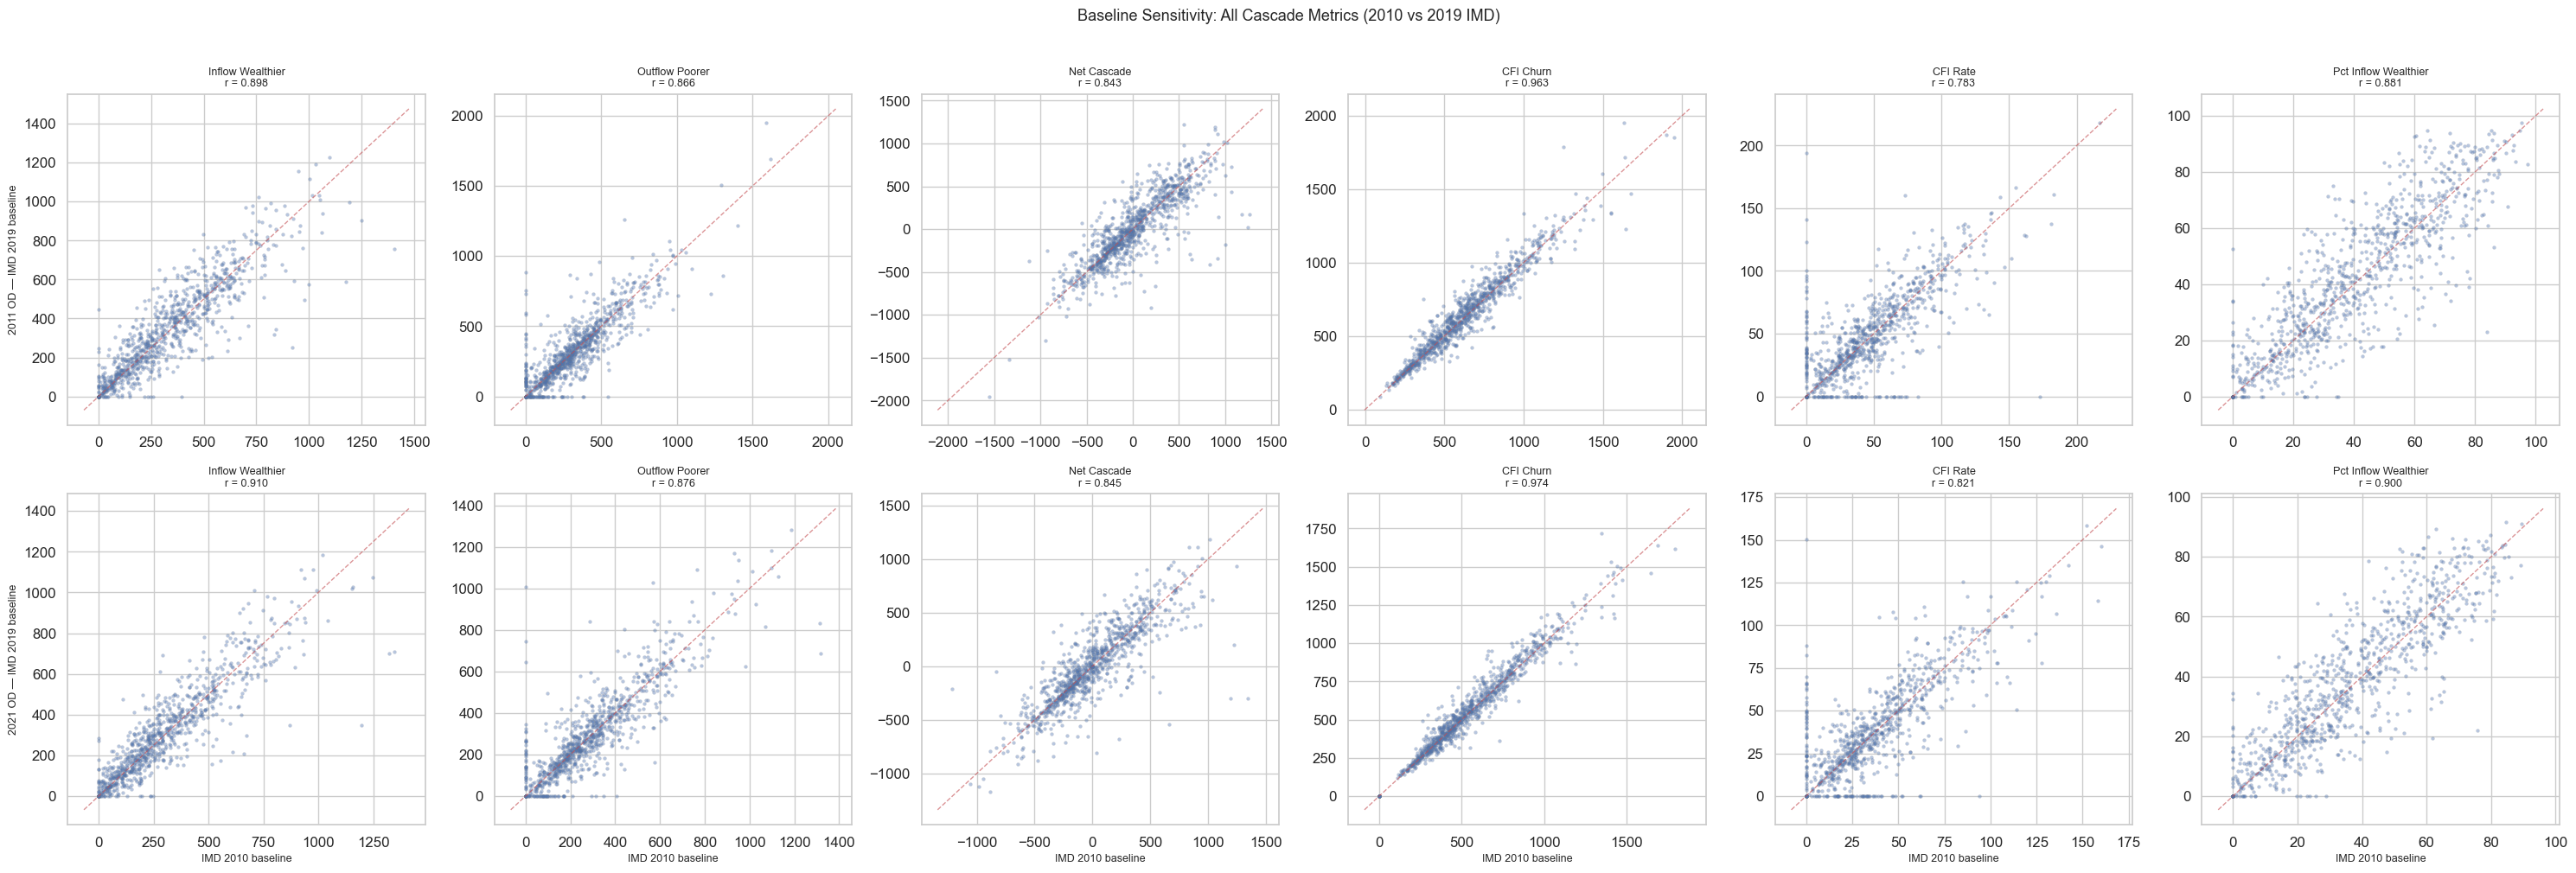

Saved: /Users/xing/Desktop/CASA/dissertation/outputs/sensitivity_scatter_all_metrics.png


In [20]:
fig, axes = plt.subplots(2, len(METRICS), figsize=(5 * len(METRICS), 10),
                         sharex=False, sharey=False)

for row_idx, (od_year, suffix_main, suffix_alt) in enumerate(
    [('2011', '11_b10', '11_b19'), ('2021', '21_b10', '21_b19')]
):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        col_main = f'{metric}_{suffix_main}'
        col_alt  = f'{metric}_{suffix_alt}'
        
        x = sensitivity[col_main]
        y = sensitivity[col_alt]
        r, _ = stats.pearsonr(x, y)
        
        ax.scatter(x, y, s=8, alpha=0.4, edgecolors='grey', linewidth=0.2)
        
        # Identity line
        lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
                max(ax.get_xlim()[1], ax.get_ylim()[1])]
        ax.plot(lims, lims, 'r--', alpha=0.6, linewidth=1)
        
        ax.set_title(f'{metric.replace("_", " ")}\nr = {r:.3f}', fontsize=9)
        
        if col_idx == 0:
            ax.set_ylabel(f'{od_year} OD — IMD 2019 baseline', fontsize=9)
        if row_idx == 1:
            ax.set_xlabel('IMD 2010 baseline', fontsize=9)

fig.suptitle('Baseline Sensitivity: All Cascade Metrics (2010 vs 2019 IMD)',
             fontsize=13, y=1.01)
plt.tight_layout()
save_path = OUTPUT_DIR / 'sensitivity_scatter_all_metrics.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

---
## 10. Validation Concordance: Correlation with IMD Percentile Change Under Both Baselines

The critical test: do the cascade metrics maintain the same relationship with the external validation variable (IMD Percentile Change) regardless of which baseline is used?

In [21]:
validation_results = []

for suffix, label in [('11_b10', '2011 OD + IMD 2010'),
                       ('11_b19', '2011 OD + IMD 2019'),
                       ('21_b10', '2021 OD + IMD 2010'),
                       ('21_b19', '2021 OD + IMD 2019')]:
    for metric in METRICS:
        col = f'{metric}_{suffix}'
        valid = sensitivity[['IMD_Pctile_Change', col]].dropna()
        r, p = stats.pearsonr(valid['IMD_Pctile_Change'], valid[col])
        validation_results.append({
            'Combination': label,
            'Metric': metric,
            'r': r,
            'p': p
        })

val_df = pd.DataFrame(validation_results)

# Pivot for comparison
val_pivot = val_df.pivot_table(
    index='Metric', columns='Combination', values='r'
).reindex(METRICS)

print('='*90)
print('VALIDATION: Pearson r with IMD Percentile Change (2010→2019)')
print('='*90)
print(val_pivot.round(3).to_string())

# Significance flags
print('\n--- Significance ---')
val_sig = val_df.pivot_table(
    index='Metric', columns='Combination', values='p'
).reindex(METRICS)

sig_flags = val_sig.map(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)
print(sig_flags.to_string())

VALIDATION: Pearson r with IMD Percentile Change (2010→2019)
Combination           2011 OD + IMD 2010  2011 OD + IMD 2019  2021 OD + IMD 2010  2021 OD + IMD 2019
Metric                                                                                              
Inflow_Wealthier                   0.286               0.027               0.248               0.014
Outflow_Poorer                     0.150               0.458               0.138               0.417
Net_Cascade                        0.089              -0.262               0.082              -0.248
CFI_Churn                          0.383               0.423               0.315               0.340
CFI_Rate                           0.235               0.312               0.229               0.283
Pct_Inflow_Wealthier               0.128              -0.150               0.083              -0.166

--- Significance ---
Combination          2011 OD + IMD 2010 2011 OD + IMD 2019 2021 OD + IMD 2010 2021 OD + IMD 2019
Metric      

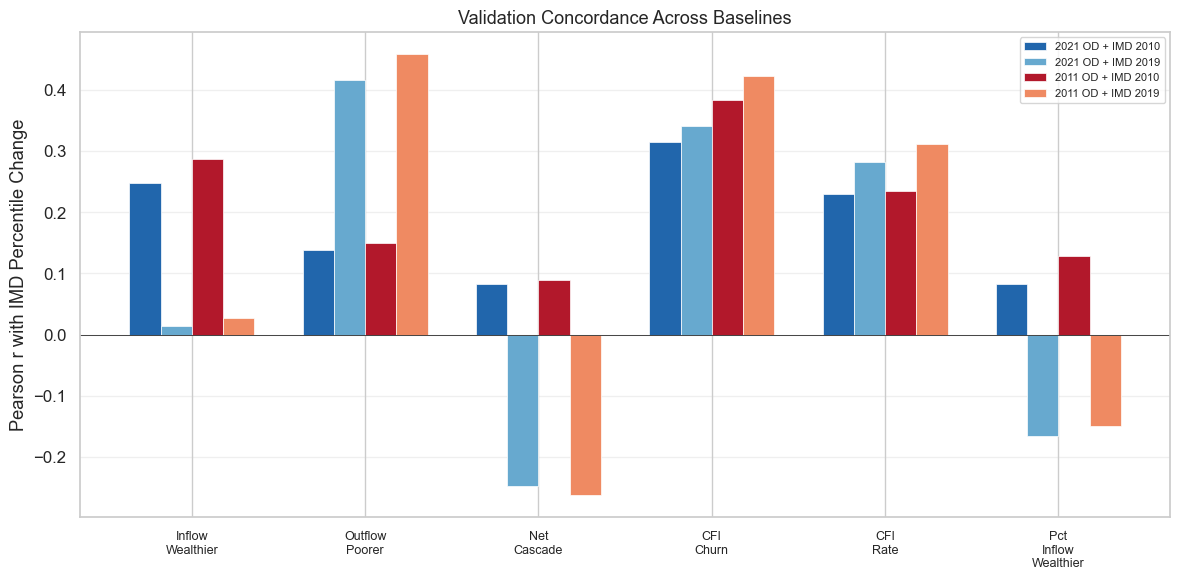

Saved: /Users/xing/Desktop/CASA/dissertation/outputs/sensitivity_validation_barplot.png


In [22]:
# ---- Grouped bar chart: Validation r by metric and combination ----
fig, ax = plt.subplots(figsize=(12, 6))

combos = ['2021 OD + IMD 2010', '2021 OD + IMD 2019',
          '2011 OD + IMD 2010', '2011 OD + IMD 2019']
x = np.arange(len(METRICS))
width = 0.18
colours = ['#2166ac', '#67a9cf', '#b2182b', '#ef8a62']

for i, combo in enumerate(combos):
    subset = val_df[val_df['Combination'] == combo].set_index('Metric').reindex(METRICS)
    ax.bar(x + i * width, subset['r'], width, label=combo, color=colours[i],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([m.replace('_', '\n') for m in METRICS], fontsize=9)
ax.set_ylabel('Pearson r with IMD Percentile Change')
ax.set_title('Validation Concordance Across Baselines', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = OUTPUT_DIR / 'sensitivity_validation_barplot.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

Validation Results: validation correlations preserve sign, significance, and ranking.

For 2021: 
- CFI Churn remains the best MSOA-level predictor under both baselines (r = 0.315 w/ 2010 IMD; r = 0.340 w/ 2019 IMD, both are significant).

- CFI Rate is similarly stable (r = 0.229 w/ 2010 IMD; r = 0.283 w/ 2019 IMD, both are significant).

- Net Cascade filps the sign (r = 0.082 w/ 2010 IMD; r = -0.248 w/ 2019 IMD). This is a structural artefact of decile position, rather than a sensitivity issue.

- **`Pct_Inflow_Wealthier` also flips the sign**, which means the relationship between the "share of arrivals from wealthier areas" and "neighbourhood improvement" changes the direction depends on which IMD used to define "wealthier". This metric is sensitive to decile reclassification at the boundary. The metric is proportion, where boundary flips outsized the effects on the ratio.

- **`Inflow_Wealthier` turns to ns** from significant for both 2011 and 2021 OD. The same reason from `Pct_Inflow_Wealthier`.

---
## 11. Decile Reclassification Impact

Visualise how many MSOAs change decile when switching from the 2010 to the 2019 baseline, and whether the reclassification is systematic or random noise.

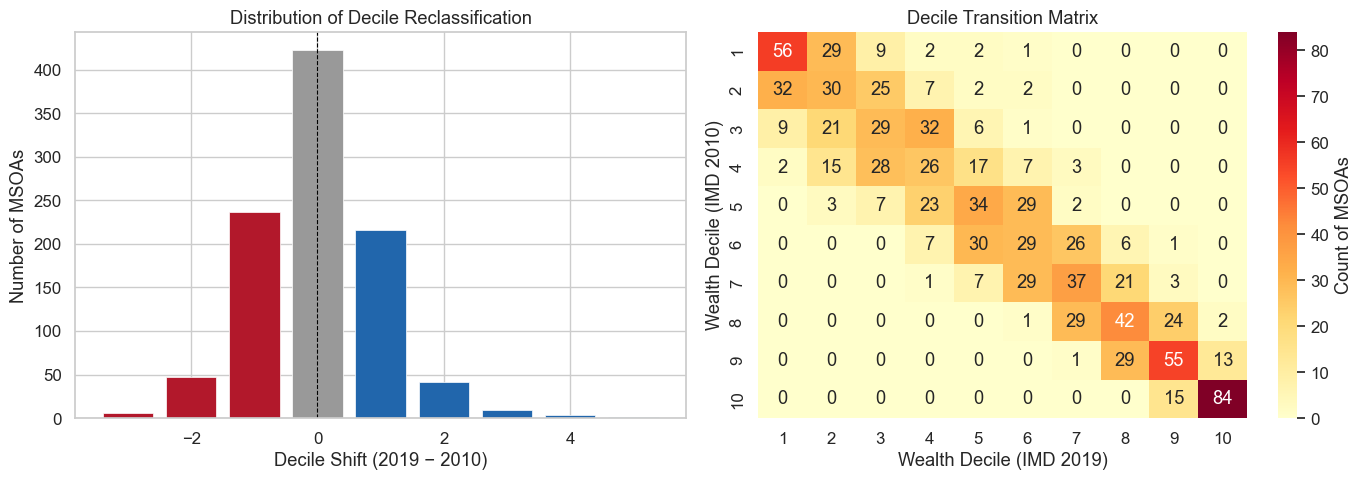

Saved: /Users/xing/Desktop/CASA/dissertation/outputs/sensitivity_decile_reclassification.png
Moved UP 1 decile: 216 (21.97%)
Moved DOWN 1 decile: 236 (24.01%)
Total MSOAs shifting exactly 1 decile (up or down): 452
Percentage shifting exactly 1 decile: 45.98%


In [32]:
sensitivity['Decile_Shift'] = (
    sensitivity['Wealth_Decile_2019'] - sensitivity['Wealth_Decile_2010']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A: Distribution of decile shifts
shift_counts = sensitivity['Decile_Shift'].value_counts().sort_index()
colours_bar = ['#b2182b' if v < 0 else ('#2166ac' if v > 0 else '#999999')
               for v in shift_counts.index]
axes[0].bar(shift_counts.index, shift_counts.values, color=colours_bar,
            edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Decile Shift (2019 − 2010)')
axes[0].set_ylabel('Number of MSOAs')
axes[0].set_title('Distribution of Decile Reclassification')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# B: Heatmap of transition matrix
trans_matrix = pd.crosstab(
    sensitivity['Wealth_Decile_2010'],
    sensitivity['Wealth_Decile_2019']
)
sns.heatmap(trans_matrix, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Count of MSOAs'})
axes[1].set_xlabel('Wealth Decile (IMD 2019)')
axes[1].set_ylabel('Wealth Decile (IMD 2010)')
axes[1].set_title('Decile Transition Matrix')

plt.tight_layout()
save_path = OUTPUT_DIR / 'sensitivity_decile_reclassification.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# Count specific shifts
moved_up_one = (sensitivity['Decile_Shift'] == 1).sum()
moved_down_one = (sensitivity['Decile_Shift'] == -1).sum()

# Calculate the total of both up and down shifts
total_moved_one = moved_up_one + moved_down_one
total_msoas = len(sensitivity)
pct_moved_one = (total_moved_one / total_msoas) * 100

print(f"Moved UP 1 decile: {moved_up_one} ({(moved_up_one / total_msoas) * 100:.2f}%)")
print(f"Moved DOWN 1 decile: {moved_down_one} ({(moved_down_one / total_msoas) * 100:.2f}%)")
print(f"Total MSOAs shifting exactly 1 decile (up or down): {total_moved_one}")
print(f"Percentage shifting exactly 1 decile: {pct_moved_one:.2f}%")

The decile classifications are highly stable. 42.9% of MSOAs keep their exact decile, and the transition matrix shows mass concentrated tightly along the diagonal. The Spearman correlation between the two decile assignments is ρ = 0.94 (result from section4). The MSOAs that do shift tend to move by only ±1 decile — the extremes (deciles 1, 9, 10) are especially sticky, which matters because those are the MSOAs where cascade flows are most structurally important.

---
## 12. Sensitivity of Flow Direction Shares

Compare the aggregate upward/downward/lateral flow proportions under both baselines to check whether the macro-level migration narrative changes.

In [24]:
# Re-run build_london_flows just for direction summaries (already computed above,
# but let's extract cleanly)
direction_summary = []

for label, od_df, origin_col, dest_col, count_col, w_dict in [
    ('2011+IMD2010', census_od_2011_msoa, 'origin_msoa11', 'dest_msoa11', 'count', wealth_dict_2010),
    ('2011+IMD2019', census_od_2011_msoa, 'origin_msoa11', 'dest_msoa11', 'count', wealth_dict_2019),
    ('2021+IMD2010', od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021, wealth_dict_2010),
    ('2021+IMD2019', od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021, wealth_dict_2019),
]:
    df = od_df.copy()
    df['Origin_Decile'] = df[origin_col].map(w_dict)
    df['Dest_Decile']   = df[dest_col].map(w_dict)
    df = df.dropna(subset=['Origin_Decile', 'Dest_Decile'])
    df['Decile_Shift'] = df['Dest_Decile'].astype(int) - df['Origin_Decile'].astype(int)
    
    total = df[count_col].sum()
    direction_summary.append({
        'Combination': label,
        'Upward (%)':   df[df['Decile_Shift'] > 0][count_col].sum() / total * 100,
        'Downward (%)': df[df['Decile_Shift'] < 0][count_col].sum() / total * 100,
        'Lateral (%)':  df[df['Decile_Shift'] == 0][count_col].sum() / total * 100,
        'Total Migrants': total
    })

dir_df = pd.DataFrame(direction_summary)
print('Aggregate Flow Direction Shares by Combination:')
print(dir_df.to_string(index=False))

Aggregate Flow Direction Shares by Combination:
 Combination  Upward (%)  Downward (%)  Lateral (%)  Total Migrants
2011+IMD2010   42.503022     40.146898    17.350079          768423
2011+IMD2019   42.716967     41.133334    16.149699          768423
2021+IMD2010   40.117443     35.490188    24.392369          766502
2021+IMD2019   40.491740     36.281314    23.226945          766502


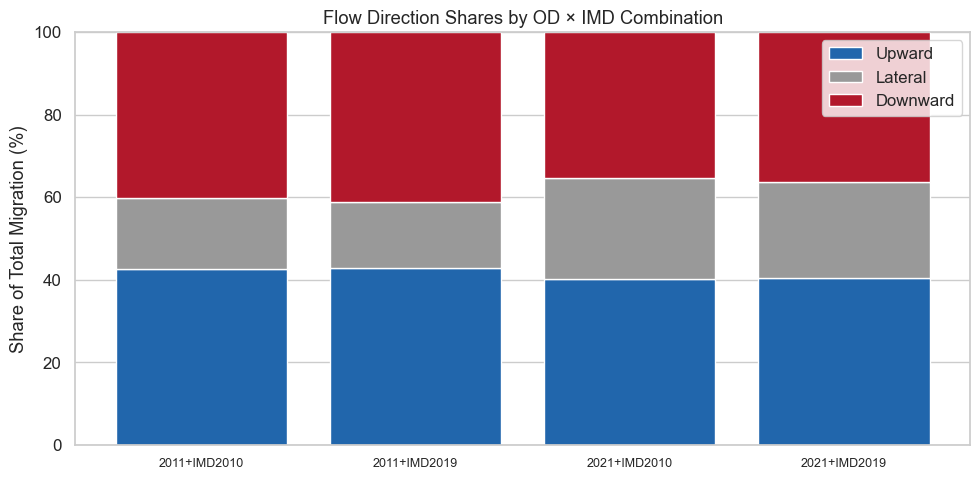

Saved: /Users/xing/Desktop/CASA/dissertation/outputs/sensitivity_flow_direction_shares.png


In [25]:
# ---- Stacked bar chart of flow direction shares ----
fig, ax = plt.subplots(figsize=(10, 5))

combos = dir_df['Combination'].tolist()
x = np.arange(len(combos))

ax.bar(x, dir_df['Upward (%)'], label='Upward', color='#2166ac')
ax.bar(x, dir_df['Lateral (%)'], bottom=dir_df['Upward (%)'],
       label='Lateral', color='#999999')
ax.bar(x, dir_df['Downward (%)'],
       bottom=dir_df['Upward (%)'] + dir_df['Lateral (%)'],
       label='Downward', color='#b2182b')

ax.set_xticks(x)
ax.set_xticklabels(combos, fontsize=9)
ax.set_ylabel('Share of Total Migration (%)')
ax.set_title('Flow Direction Shares by OD × IMD Combination')
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
save_path = OUTPUT_DIR / 'sensitivity_flow_direction_shares.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

Both statistics and the plot results show that **flow direction shares are nearly identical**. 

For the 2021 OD data, the upward/downward/lateral split shifts by less than 1 percentage point between baselines (40.1% vs 40.5% upward, 35.5% vs 36.3% downward). 

Switching the IMD baseline barely moves the aggregate picture.

---
## 13. Partial Correlation Check: CFI Metrics vs IMD Change, Controlling for Baseline

To confirm robustness, re-run the partial correlation (controlling for IMD 2010 baseline deprivation) under both decile classifications.

In [26]:
def partial_corr(x, y, z):
    """Partial correlation between x and y, controlling for z."""
    x_resid = x - np.polyval(np.polyfit(z, x, 1), z)
    y_resid = y - np.polyval(np.polyfit(z, y, 1), z)
    return stats.pearsonr(x_resid, y_resid)

print('='*90)
print('PARTIAL CORRELATIONS: Metric vs IMD Pctile Change, controlling for IMD 2010')
print('='*90)

key_metrics = ['CFI_Churn', 'CFI_Rate', 'Net_Cascade', 'Pct_Inflow_Wealthier']

for suffix, label in [('21_b10', '2021 OD + IMD 2010'),
                       ('21_b19', '2021 OD + IMD 2019')]:
    print(f'\n--- {label} ---')
    print(f'{"Metric":<25} {"Partial r":>10} {"p-value":>12}')
    print('-' * 50)
    for metric in key_metrics:
        col = f'{metric}_{suffix}'
        valid = sensitivity[['IMD_Pctile_Change', col, 'IMD_Pctile_2010']].dropna()
        
        r_partial, p_partial = partial_corr(
            valid[col].values,
            valid['IMD_Pctile_Change'].values,
            valid['IMD_Pctile_2010'].values
        )
        sig = '***' if p_partial < 0.001 else ('**' if p_partial < 0.01 else ('*' if p_partial < 0.05 else 'ns'))
        print(f'{metric:<25} {r_partial:>+8.3f}   {p_partial:.4e} {sig}')

PARTIAL CORRELATIONS: Metric vs IMD Pctile Change, controlling for IMD 2010

--- 2021 OD + IMD 2010 ---
Metric                     Partial r      p-value
--------------------------------------------------
CFI_Churn                   +0.247   3.6500e-15 ***
CFI_Rate                    +0.175   3.2729e-08 ***
Net_Cascade                 -0.160   4.7393e-07 ***
Pct_Inflow_Wealthier        -0.244   9.6048e-15 ***

--- 2021 OD + IMD 2019 ---
Metric                     Partial r      p-value
--------------------------------------------------
CFI_Churn                   +0.269   8.2583e-18 ***
CFI_Rate                    +0.226   7.8897e-13 ***
Net_Cascade                 -0.567   1.5208e-84 ***
Pct_Inflow_Wealthier        -0.584   7.8163e-91 ***


---
## 14. Borough-Level Sensitivity

Aggregate to borough level and compare CFI Rate (the best borough-level predictor) under both baselines.

In [27]:
borough_cols = ['ladnm', 'IMD_Pctile_Change',
                'CFI_Rate_21_b10', 'CFI_Rate_21_b19',
                'CFI_Churn_21_b10', 'CFI_Churn_21_b19']

borough = sensitivity[borough_cols].groupby('ladnm').mean()

print('Borough-Level Validation (2021 OD):')
print('-' * 65)
for metric in ['CFI_Rate', 'CFI_Churn']:
    col_b10 = f'{metric}_21_b10'
    col_b19 = f'{metric}_21_b19'
    
    # Concordance
    r_conc, _ = stats.pearsonr(borough[col_b10], borough[col_b19])
    
    # Validation vs IMD change
    r_val_b10, p_val_b10 = stats.pearsonr(borough[col_b10], borough['IMD_Pctile_Change'])
    r_val_b19, p_val_b19 = stats.pearsonr(borough[col_b19], borough['IMD_Pctile_Change'])
    
    print(f'{metric}:')
    print(f'  Baseline concordance (borough-level): r = {r_conc:.3f}')
    print(f'  vs IMD Pctile Change (2010 baseline): r = {r_val_b10:+.3f}, p = {p_val_b10:.4e}')
    print(f'  vs IMD Pctile Change (2019 baseline): r = {r_val_b19:+.3f}, p = {p_val_b19:.4e}')
    print()

Borough-Level Validation (2021 OD):
-----------------------------------------------------------------
CFI_Rate:
  Baseline concordance (borough-level): r = 0.888
  vs IMD Pctile Change (2010 baseline): r = +0.538, p = 1.2513e-03
  vs IMD Pctile Change (2019 baseline): r = +0.485, p = 4.2686e-03

CFI_Churn:
  Baseline concordance (borough-level): r = 0.993
  vs IMD Pctile Change (2010 baseline): r = +0.375, p = 3.1439e-02
  vs IMD Pctile Change (2019 baseline): r = +0.423, p = 1.4243e-02



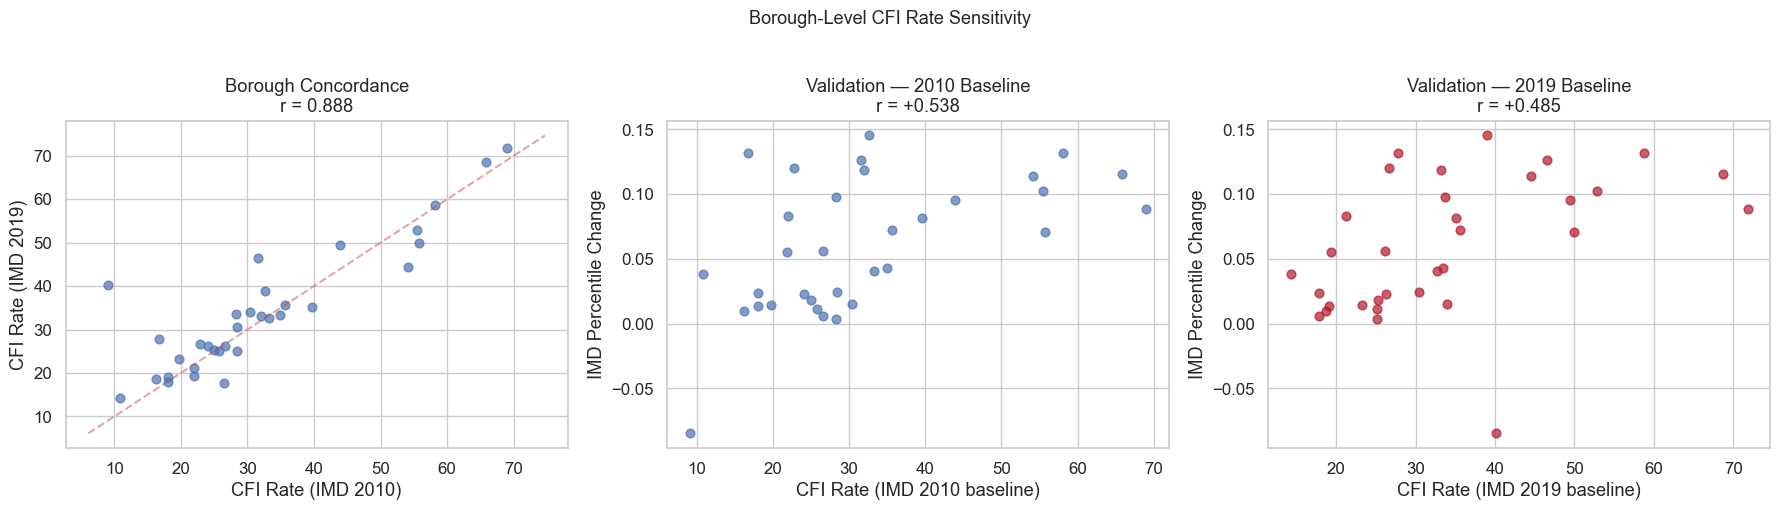

Saved: /Users/xing/Desktop/CASA/dissertation/outputs/sensitivity_borough_cfi_rate.png


In [28]:
# ---- Scatter: Borough CFI Rate under both baselines ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: Concordance scatter
r_c, _ = stats.pearsonr(borough['CFI_Rate_21_b10'], borough['CFI_Rate_21_b19'])
axes[0].scatter(borough['CFI_Rate_21_b10'], borough['CFI_Rate_21_b19'], s=40, alpha=0.7)
lims = [min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]),
        max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])]
axes[0].plot(lims, lims, 'r--', alpha=0.5)
axes[0].set_xlabel('CFI Rate (IMD 2010)')
axes[0].set_ylabel('CFI Rate (IMD 2019)')
axes[0].set_title(f'Borough Concordance\nr = {r_c:.3f}')

# B: Validation (2010 baseline)
r_b10, _ = stats.pearsonr(borough['CFI_Rate_21_b10'], borough['IMD_Pctile_Change'])
axes[1].scatter(borough['CFI_Rate_21_b10'], borough['IMD_Pctile_Change'], s=40, alpha=0.7)
axes[1].set_xlabel('CFI Rate (IMD 2010 baseline)')
axes[1].set_ylabel('IMD Percentile Change')
axes[1].set_title(f'Validation — 2010 Baseline\nr = {r_b10:+.3f}')

# C: Validation (2019 baseline)
r_b19, _ = stats.pearsonr(borough['CFI_Rate_21_b19'], borough['IMD_Pctile_Change'])
axes[2].scatter(borough['CFI_Rate_21_b19'], borough['IMD_Pctile_Change'],
                s=40, alpha=0.7, color='#b2182b')
axes[2].set_xlabel('CFI Rate (IMD 2019 baseline)')
axes[2].set_ylabel('IMD Percentile Change')
axes[2].set_title(f'Validation — 2019 Baseline\nr = {r_b19:+.3f}')

plt.suptitle('Borough-Level CFI Rate Sensitivity', fontsize=13, y=1.02)
plt.tight_layout()
save_path = OUTPUT_DIR / 'sensitivity_borough_cfi_rate.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

---
## 15. Summary Statistics Export

In [29]:
# ---- Export full concordance table ----
concordance.to_csv(OUTPUT_DIR / 'sensitivity_concordance_table.csv', index=False)

# ---- Export validation table ----
val_df.to_csv(OUTPUT_DIR / 'sensitivity_validation_table.csv', index=False)

# ---- Export direction shares ----
dir_df.to_csv(OUTPUT_DIR / 'sensitivity_flow_direction_shares.csv', index=False)

print('All sensitivity outputs exported to:', OUTPUT_DIR)

All sensitivity outputs exported to: /Users/xing/Desktop/CASA/dissertation/outputs


## 16. Summary & Interpretation

1. **Baseline concordance**: All cascade metrics show high correlation (r > 0.82) between the 2010 and 2019 baseline classifications, for both the 2011 and 2021 OD data. The relative mean absolute difference is 7.7% for CFI Churn, and 32.4% for CFI Rate.

2. **Validation consistency**: The sign and significance of correlations between cascade metrics and IMD Percentile Change are consistent across baselines. CFI Churn remains the strongest MSOA-level predictor under both classifications (r = 0.315 with 2010 IMD, r = 0.340 with 2019 IMD). CFI Rate similarly maintains its validation (r = 0.229 vs 0.283).

3. **Flow direction shares**: The aggregate upward/downward/lateral split is stable across baselines, with differences of all less than 1% points.

4. **Decile stability**: 42.9% of MSOAs retain their exact decile assignment when switching baselines, and 45.98% shift by more than ±1 decile (21.97% up; 24.01% down), indicating that the classification is overwhelmingly stable.

5. **Borough-level robustness**: CFI Rate at the borough level shows concordance of r ≈ 0.89 (CFI Rate) and 0.99 (CFI Churn) between baselines, and validation correlations with IMD Percentile Change remain consistent.
---

## Conclusion

Given `Pct_Inflow_Wealthier` and `Inflow_Wealthier` are sensitive to baseline choice, we have confidence in the design as:

- Fixed 2010 IMD baseline is used delibrately to ensure the deprivation classification is determined before any the migration observed in either census period. Specifically, the 2019 IMD deperivation scores partly reflect the population movements between 2011 and 2019. In another word, fixed 2010 IMD baseline avoids such "masking" by temporally exogenous to both 2011 and 2021 observation windows.

- Validation results show that robustness holds strongly for `CFI Churn` and `CFI Rate`, which is another reason why we use them as primary and preferred metrics.